In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.pipeline import Pipeline


In [12]:
df = pd.read_excel("income_predictor.xlsx")

In [13]:
# 🧩 1. Data hazırlığı
np.random.seed(42)
n = 500
df = pd.DataFrame({
    "Age": np.random.randint(20, 66, n),
    "EducationLevel": np.random.randint(1, 6, n),
    "Experience_years": np.random.randint(0, 41, n),
    "WeeklyHours": np.random.randint(20, 61, n),
    "CityCostIndex" : np.random.randint(1, 11, n),
})

noise = np.random.normal(0,800,n)

df["Income_AZN"] = (
    df["EducationLevel"] * 600 + df["Experience_years"] * 250 + df["WeeklyHours"] * 50 + df["CityCostIndex"] * 300 + noise
)

for col in df.columns[:-1]:
    df.loc[df.sample(frac=0.05).index, col] = np.nan

df.fillna(df.mean(), inplace=True)

# X ve y
X = df[[
    "Age",
    "EducationLevel",
    "Experience_years",
    "WeeklyHours",
    "CityCostIndex"
]]

y = df["Income_AZN"]

# Train/Test
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [14]:
# 🧩 2. Linear Regression qur
linear = LinearRegression()
linear.fit(X_train,y_train)

train_pred = linear.predict(X_train)
test_pred = linear.predict(X_test)

linear_train = r2_score(y_train,train_pred)
linear_test = r2_score(y_test,test_pred)

print("------ Linear Regression ------")
print("Train R²:", round(linear_train,3))
print("Test R² :", round(linear_test,3))

cv = cross_val_score(linear,X,y,cv=5,scoring="r2")
print("Cross Validation Scores:",cv)
print("Average CV:",round(np.mean(cv),3))

------ Linear Regression ------
Train R²: 0.884
Test R² : 0.879
Cross Validation Scores: [0.8817424  0.92652242 0.8358797  0.85565777 0.90145403]
Average CV: 0.88


In [15]:
# 🧩 3. Polynomial Regression (degree=2 və degree=3)
poly_results = {}

for degree in [2,3]:
    poly = PolynomialFeatures(degree=degree)

    X_train_poly = poly.fit_transform(X_train)
    X_test_poly = poly.fit_transform(X_test)

    model = LinearRegression()

    model.fit(X_train_poly,y_train)

    train_r2 = r2_score(y_train,model.predict(X_train_poly))
    test_r2 = r2_score(y_test,model.predict(X_test_poly))

    poly_results[degree] = (train_r2,test_r2)

    print(f"\nPolynomial Degree {degree}")
    print("Train R²:", round(train_r2,3))
    print("Test R² :", round(test_r2,3))



Polynomial Degree 2
Train R²: 0.887
Test R² : 0.874

Polynomial Degree 3
Train R²: 0.895
Test R² : 0.864


In [23]:
# 🧩 4. Ridge və Lasso ilə Regularization
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

ridge = Ridge(alpha=10)
ridge.fit(X_train_scaled,y_train)

lasso = Lasso(alpha=1000)
lasso.fit(X_train_scaled,y_train)

ridge_train = r2_score(
    y_train,
    ridge.predict(X_train_scaled)
)

ridge_test = r2_score(
    y_test,
    ridge.predict(X_test_scaled)
)

lasso_train = r2_score(
    y_train,
    lasso.predict(X_train_scaled)
)

lasso_test = r2_score(
    y_test,
    lasso.predict(X_test_scaled)
)

print("\n------ Ridge ------")
print("Train:", round(ridge_train,3))
print("Test :", round(ridge_test,3))

print("\n------ Lasso ------")
print("Train:", round(lasso_train,3))
print("Test :", round(lasso_test,3))

results = pd.DataFrame({
    "Model":[
        "Linear",
        "Poly(2)",
        "Poly(3)",
        "Ridge",
        "Lasso"
    ],
    "Train R²":[
        linear_train,
        poly_results[2][0],
        poly_results[3][0],
        ridge_train,
        lasso_train
    ],
    "Test R²":[
        linear_test,
        poly_results[2][1],
        poly_results[3][1],
        ridge_test,
        lasso_test
    ]
})


------ Ridge ------
Train: 0.884
Test : 0.876

------ Lasso ------
Train: 0.658
Test : 0.585


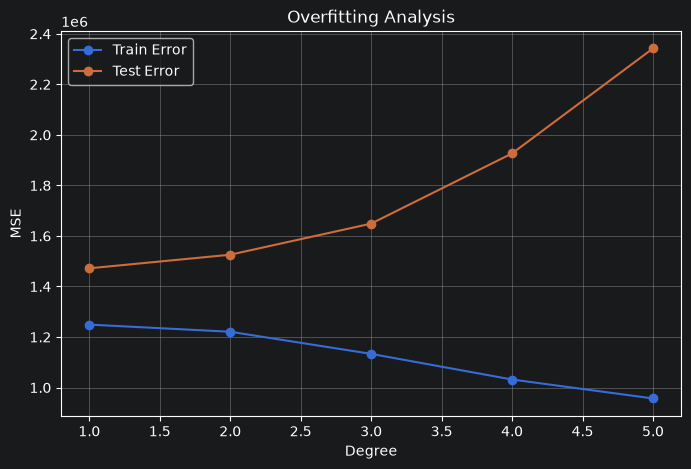

In [22]:
# 🧩 5. Overfitting analizi
degrees = [1,2,3,4,5]

train_errors = []
test_errors = []

for d in degrees:

    model = Pipeline([
        ("poly", PolynomialFeatures(degree=d)),
        ("linear", LinearRegression())
    ])

    model.fit(X_train,y_train)

    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    train_errors.append(
        mean_squared_error(y_train,train_pred)
    )

    test_errors.append(
        mean_squared_error(y_test,test_pred)
    )

plt.figure(figsize=(8,5))

plt.plot(
    degrees,
    train_errors,
    marker="o",
    label="Train Error"
)

plt.plot(
    degrees,
    test_errors,
    marker="o",
    label="Test Error"
)

plt.xlabel("Degree")
plt.ylabel("MSE")
plt.title("Overfitting Analysis")
plt.legend()
plt.grid(True)
plt.show()

In [30]:
print("""
    1.Overfitting və underfitting fərqi nədir?
    Underfitting modelin məlumatı kifayət qədər öyrənməməsidir. Overfitting isə modelin train datasını həddindən artıq öyrənib yeni datada zəif nəticə verməsidir.
    \n
    2.Niyə polynomial regression real həyatda faydalıdır?
    Mürəkkəb və qeyri-xətti əlaqələri öyrənərək daha dəqiq proqnoz verməyə kömək edir.
    \n
    3.L1 və L2 regularization modelə necə təsir edir?
    L1 (Lasso) lazımsız xüsusiyyətləri azaldır, L2 (Ridge) isə model çəkilərini kiçildərək overfitting-i azaldır.
    \n
    4.Hansı model (Linear, Poly, Ridge, Lasso) ən balanslı nəticə verdi?
    Ridge Regression ən stabil nəticəni verdi, çünki overfitting riskini azaldır və test nəticəsi daha yaxşı olur.
""")


    1.Overfitting və underfitting fərqi nədir?
    Underfitting modelin məlumatı kifayət qədər öyrənməməsidir. Overfitting isə modelin train datasını həddindən artıq öyrənib yeni datada zəif nəticə verməsidir.
    

    2.Niyə polynomial regression real həyatda faydalıdır?
    Mürəkkəb və qeyri-xətti əlaqələri öyrənərək daha dəqiq proqnoz verməyə kömək edir.
    

    3.L1 və L2 regularization modelə necə təsir edir?
    L1 (Lasso) lazımsız xüsusiyyətləri azaldır, L2 (Ridge) isə model çəkilərini kiçildərək overfitting-i azaldır.
    

    4.Hansı model (Linear, Poly, Ridge, Lasso) ən balanslı nəticə verdi?
    Ridge Regression ən stabil nəticəni verdi, çünki overfitting riskini azaldır və test nəticəsi daha yaxşı olur.

